# make plots of days above compliance and exports

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import matplotlib.dates as mdates
from scipy.stats import linregress
from scipy.stats import kruskal

In [3]:
#first load compliance by month, each row is a station, last row is x2
sta=['Chipps Island','Emmaton','Jersey Point','Franks Tract','CCWD','CCFB','X2']
df_compliance1=pd.read_csv('./x2_days_above_compliance_by_month_2026_04_14_baseline.csv')
df_compliance2=pd.read_csv('./x2_days_above_compliance_by_month_2026_04_14_dcp.csv')
df_compliance3=pd.read_csv('./x2_days_above_compliance_by_month_2026_04_14_cor.csv')
df_compliance3

,1,10,11,12
0,12.958333,31.000000,30.000000,31.000000
1,1.697917,23.239583,29.760417,0.354167
2,0.000000,31.000000,30.000000,21.927083
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,29.093750,9.166667,11.020833
5,0.000000,7.625000,0.000000,0.000000
6,3.000000,24.000000,30.000000,21.000000


In [4]:
for c in df_compliance1.columns:
    print(c)

1
10
11
12


In [5]:
#divide each column by the number of days in the month
df_compliance1norm=df_compliance1.copy()/31
df_compliance2norm=df_compliance2.copy()/31
df_compliance3norm=df_compliance3.copy()/31

#now correct the months that dont have 30 days
for c in df_compliance1norm.columns:
    if c in ['4','6','9','11']:
        #months w/ 30 days
        df_compliance1norm[c]=df_compliance1norm[c]*31/30
        df_compliance2norm[c]=df_compliance2norm[c]*31/30
        df_compliance3norm[c]=df_compliance3norm[c]*31/30
    elif c=='2':
        df_compliance1norm[c]=df_compliance1norm[c]*31/28 #assumes not a leap year
        df_compliance2norm[c]=df_compliance2norm[c]*31/30
        df_compliance3norm[c]=df_compliance3norm[c]*31/30
        
df_compliance3norm


,1,10,11,12
0,0.418011,1.000000,1.000000,1.000000
1,0.054772,0.749664,0.992014,0.011425
2,0.000000,1.000000,1.000000,0.707325
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.938508,0.305556,0.355511
5,0.000000,0.245968,0.000000,0.000000
6,0.096774,0.774194,1.000000,0.677419


In [6]:
df_compliance1norm

,1,10,11,12
0,0.418011,1.000000,1.000000,1.000000
1,0.054772,0.749664,0.992014,0.011425
2,0.000000,1.000000,1.000000,0.707325
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.938508,0.305556,0.355511
5,0.000000,0.245968,0.000000,0.000000
6,0.193548,0.967742,1.000000,0.774194


In [7]:
#each row is a scenario, order is baseline,dcp,cor
scen=['Baseline','DCP','CoR']
df_exports=pd.read_csv('./exports_all_scenarios_2026_04_17.csv')
df_exports

,1,10,11,12
0,170.842148,225.341751,114.475105,222.109146
1,340.576630,182.908661,254.020157,275.334930
2,157.851028,155.278122,203.955307,234.325562


In [8]:
# normalize exports by the health and safetime limit of 1500 cfs (42.48 m^3/s )
df_exports_norm=df_exports/(42.48)
df_exports_norm

,1,10,11,12
0,4.021708,5.304655,2.694800,5.228558
1,8.017341,4.305759,5.979759,6.481519
2,3.715891,3.655323,4.801208,5.516138


In [9]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr

In [10]:
def addr2(x,y,string,s):
    minx=np.min(x)
    maxy=np.max(y)
    #r2=r2_score(x,y)
    #pr, _=pearsonr(x,y)
    sr, _ =spearmanr(x,y)
    #plt.annotate("Pearson R = {:.3f}".format(pr), (minx, 1.1*maxy))
    ax[s].annotate(String + " Spearman R = {:.3f}".format(sr), (minx, 1.05*maxy))
    ax[s].xlim(minx-0.05*np.max(x),1.05*np.max(x))
    ax[s].ylim(np.min(y)-0.05*np.max(y),1.15*maxy)
    return

(0, np.int64(0))
0.9753099120283332
(0, np.int64(1))
0.7906693254402206
(1, np.int64(0))
0.9843196395852131
Skip Franks Tract
(1, np.int64(1))
0.9853238144145063
(2, np.int64(0))
0.9753099120283332
(2, np.int64(1))
0.7840903311765559


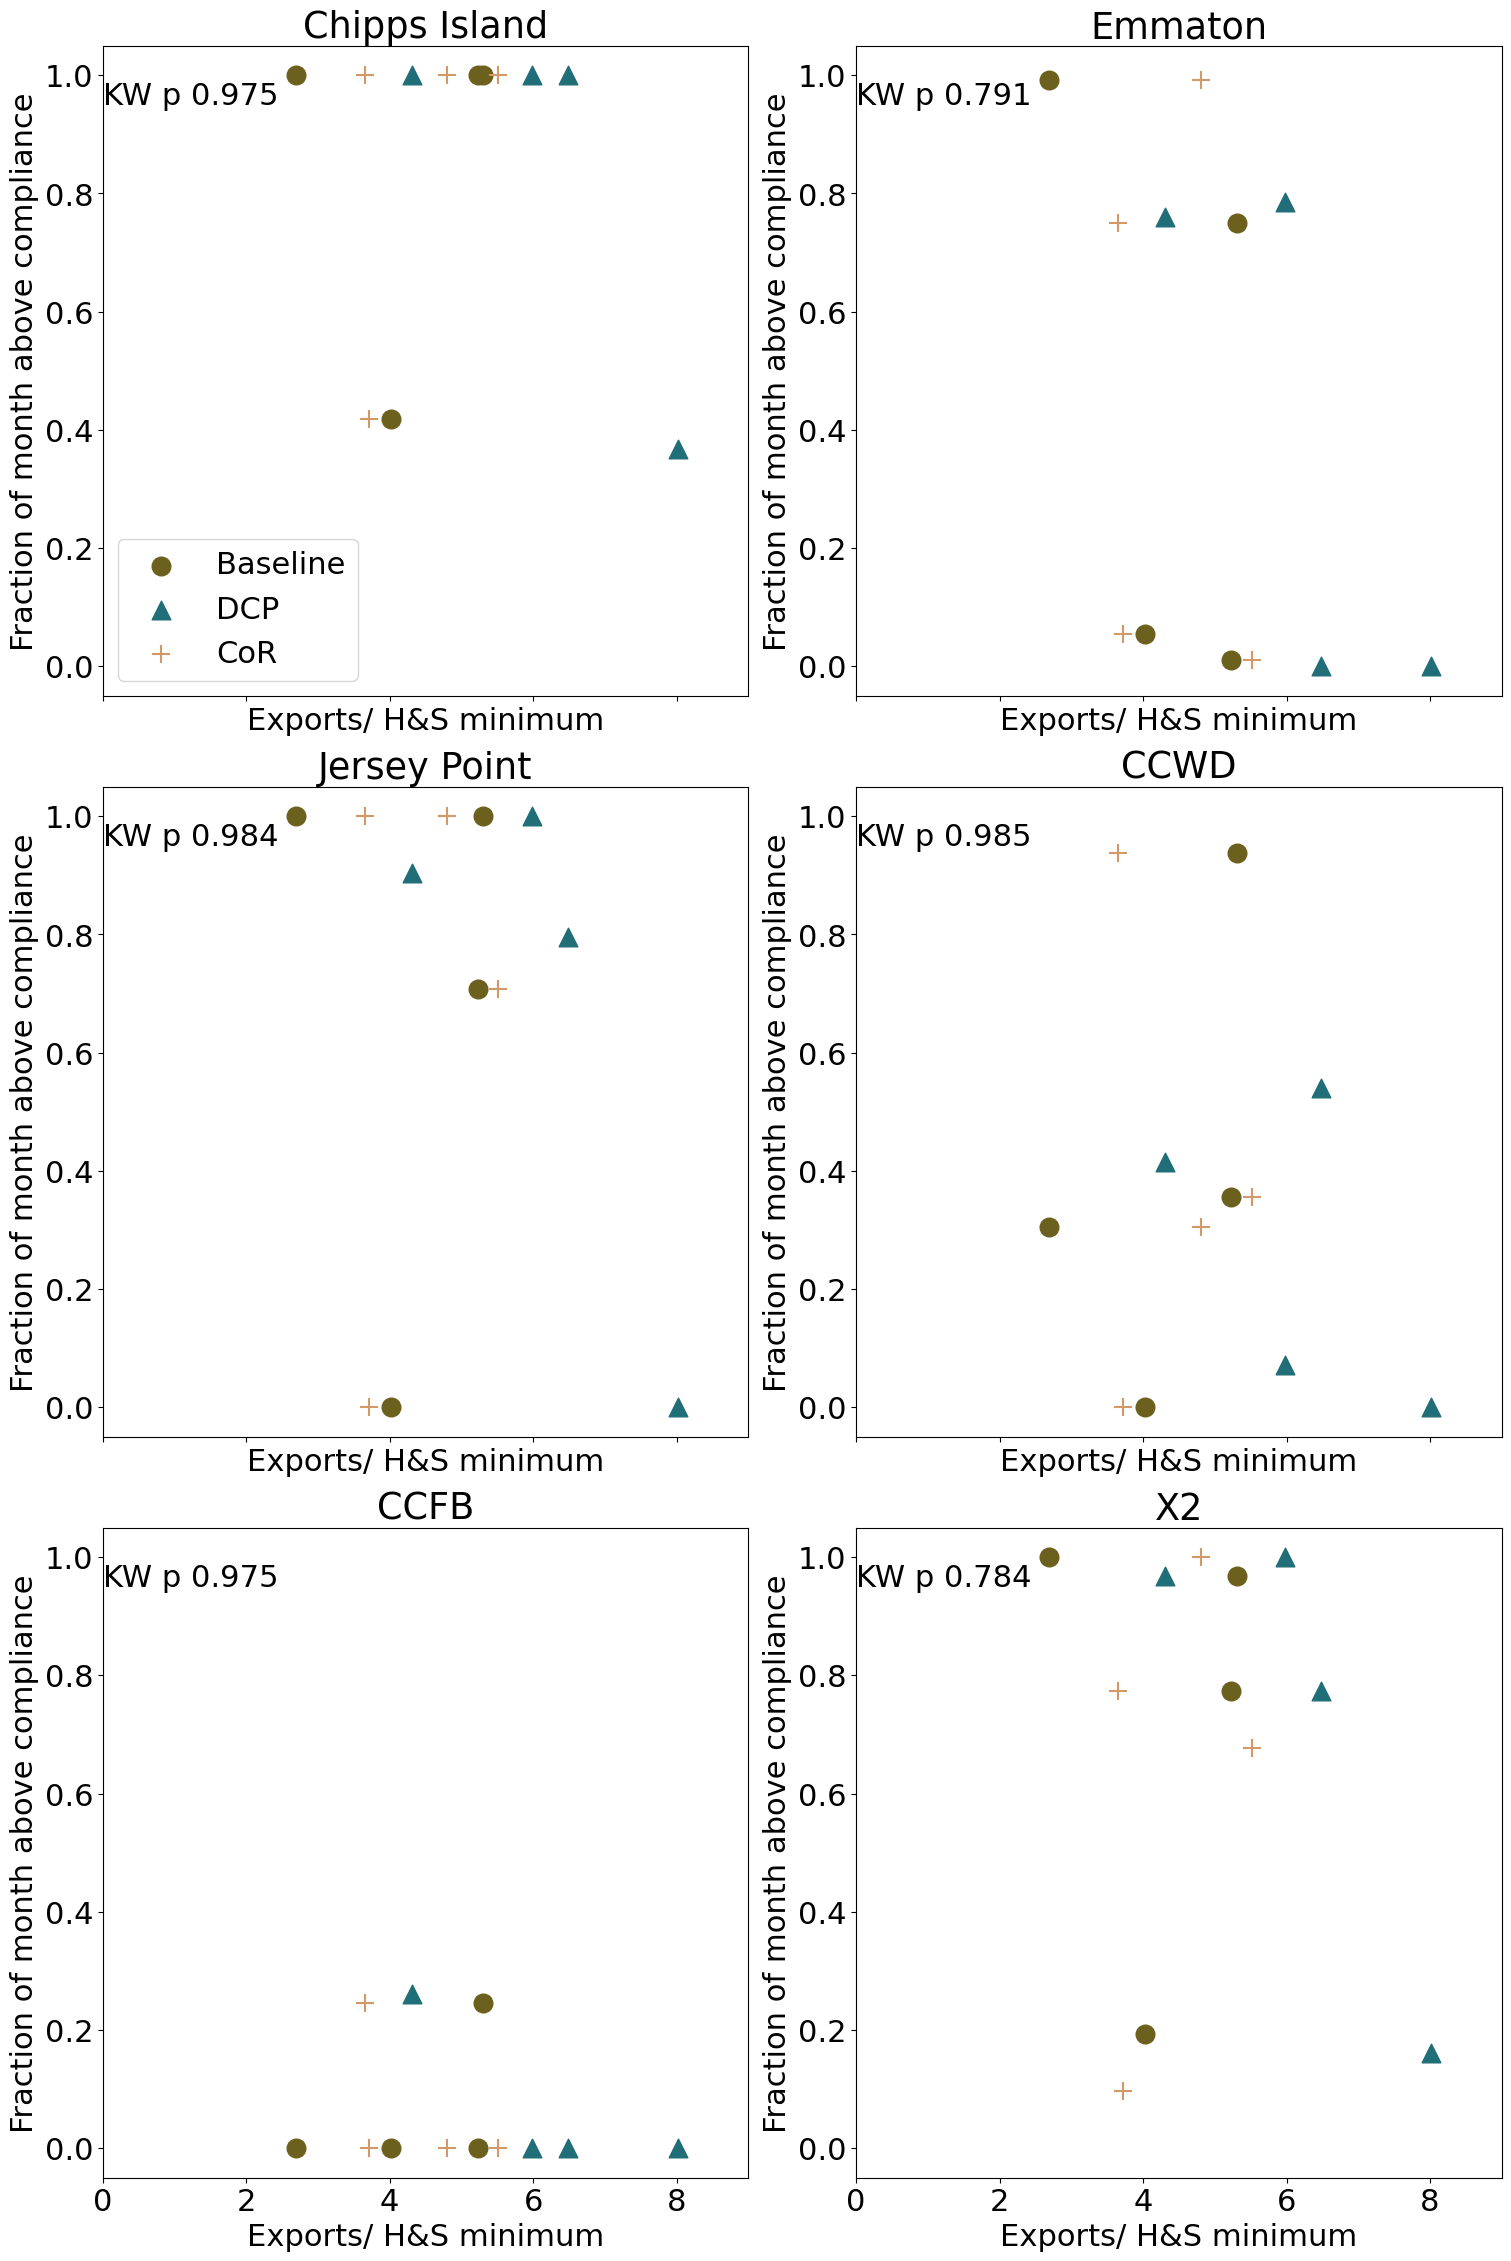

In [24]:
# Instead of spearman r add slope and r2
# make 6 tiled plots of fraction days above compliance versus export fraction, skip franks tract

fig, ax = plt.subplots(3,2,figsize=(15,22.5),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in np.arange(0,len(sta)):
    if idx>3:
        s=(int(np.floor((idx-1)/2)),(idx-1) % 2) 
    elif idx==3:
        idx=np.nan
        print('Skip Franks Tract')
    else:
        s=(int(np.floor(idx/2)),idx % 2)
    if ~np.isnan(idx):
        print(s)
        #for each scenario, plot the export fraction on the x axis and fraction of days above compliance on y 
        count=0
        #for computing the correlation coefficient, need to collect all the x and ys to pass to function
        x1=df_exports_norm.loc[0,:]
        y1=df_compliance1norm.loc[idx,:]
        result1 = linregress(x1,y1)
        x2=df_exports_norm.loc[1,:]
        y2=df_compliance2norm.loc[idx,:]
        result2 = linregress(x2,y2)
        x3=df_exports_norm.loc[2,:]
        y3=df_compliance3norm.loc[idx,:]
        result3 = linregress(x3,y3)
        minx=np.min(x1)
        maxy=np.max(y1)
        col=cmocean.cm.tarn(1/6)
        ax[s].scatter(x1,y1,color=col,label=scen[0],s=180)
        #try kruskal wallis test for the compliance 
        result=kruskal(y1,y2,y3)
        print(result.pvalue)
        ax[s].annotate('KW p {:.3f}'.format(result.pvalue),(0,0.95))
        #ax[s].annotate("B m = {:.3f} ({:.2f})".format(result1.slope,result1.rvalue), (minx,maxy*0.95))
        # ax[s].xlim(minx-0.05*np.max(x),1.05*np.max(x))
        # ax[s].ylim(np.min(y)-0.05*np.max(y),1.15*maxy)
        col=cmocean.cm.tarn(10/12)
        ax[s].scatter(x2,y2,color=col,label=scen[1],marker='^',s=180)
        #ax[s].annotate("DCP m = {:.3f} ({:.2f})".format(result2.slope,result2.rvalue), (minx,maxy*0.90))
        col=cmocean.cm.tarn(2/6)
        ax[s].scatter(x3,y3,color=col,label=scen[2],marker='+',s=180)
        #ax[s].annotate("CoR m = {:.3f} ({:.2f})".format(result3.slope,result3.rvalue), (minx,maxy*0.85))
        if idx==0 and count==0:
            ax[s].legend()#frameon=False)
            count=count+1
            
        ax[s].set_xlabel('Exports/ H&S minimum')
        ax[s].set_ylabel('Fraction of month above compliance')
        ax[s].set_ylim(-0.05,1.05)
        ax[s].set_xlim(0,9)
        ax[s].set_title(sta[idx])
plt.show()        
        
# ax[1,0].set_ylabel('Fraction of month above compliance')
# ax[1,1].set_ylabel('Fraction of month above compliance')
fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3/figures/compliance_exports_correlation_kruskalwallis.png')